In [8]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from helpers.viz import draw_bbox
from helpers.utils import f1_score, f2_score
DATA_DIR = PROJECT_ROOT / "data"
DATA_YAML = DATA_DIR / "dataset.yaml"
TEST_IMAGES_DIR = DATA_DIR / "test" / "images"
RUNS = PROJECT_ROOT / "models" / "runs"

In [5]:
WEIGHTS = RUNS / "yolo26n_unfreeze50" / "weights" / "best.pt"

In [6]:
model = YOLO(str(WEIGHTS))
test_images = sorted(TEST_IMAGES_DIR.glob("*.jpg"))

In [9]:
def print_metrics(tag, m):
    p, r = float(m.box.mp), float(m.box.mr)
    print(f"\n=== {tag} ===")
    print(f"P={p}  R={r}  mAP50={m.box.map50}  mAP50-95={m.box.map}")
    print(f"F1={f1_score(p, r)}  F2={f2_score(p, r)}")
    for i, name in m.names.items():
        pi, ri = float(m.box.p[i]), float(m.box.r[i])
        print(f"  {name}: P={pi} R={ri} F2={f2_score(pi, ri)}")

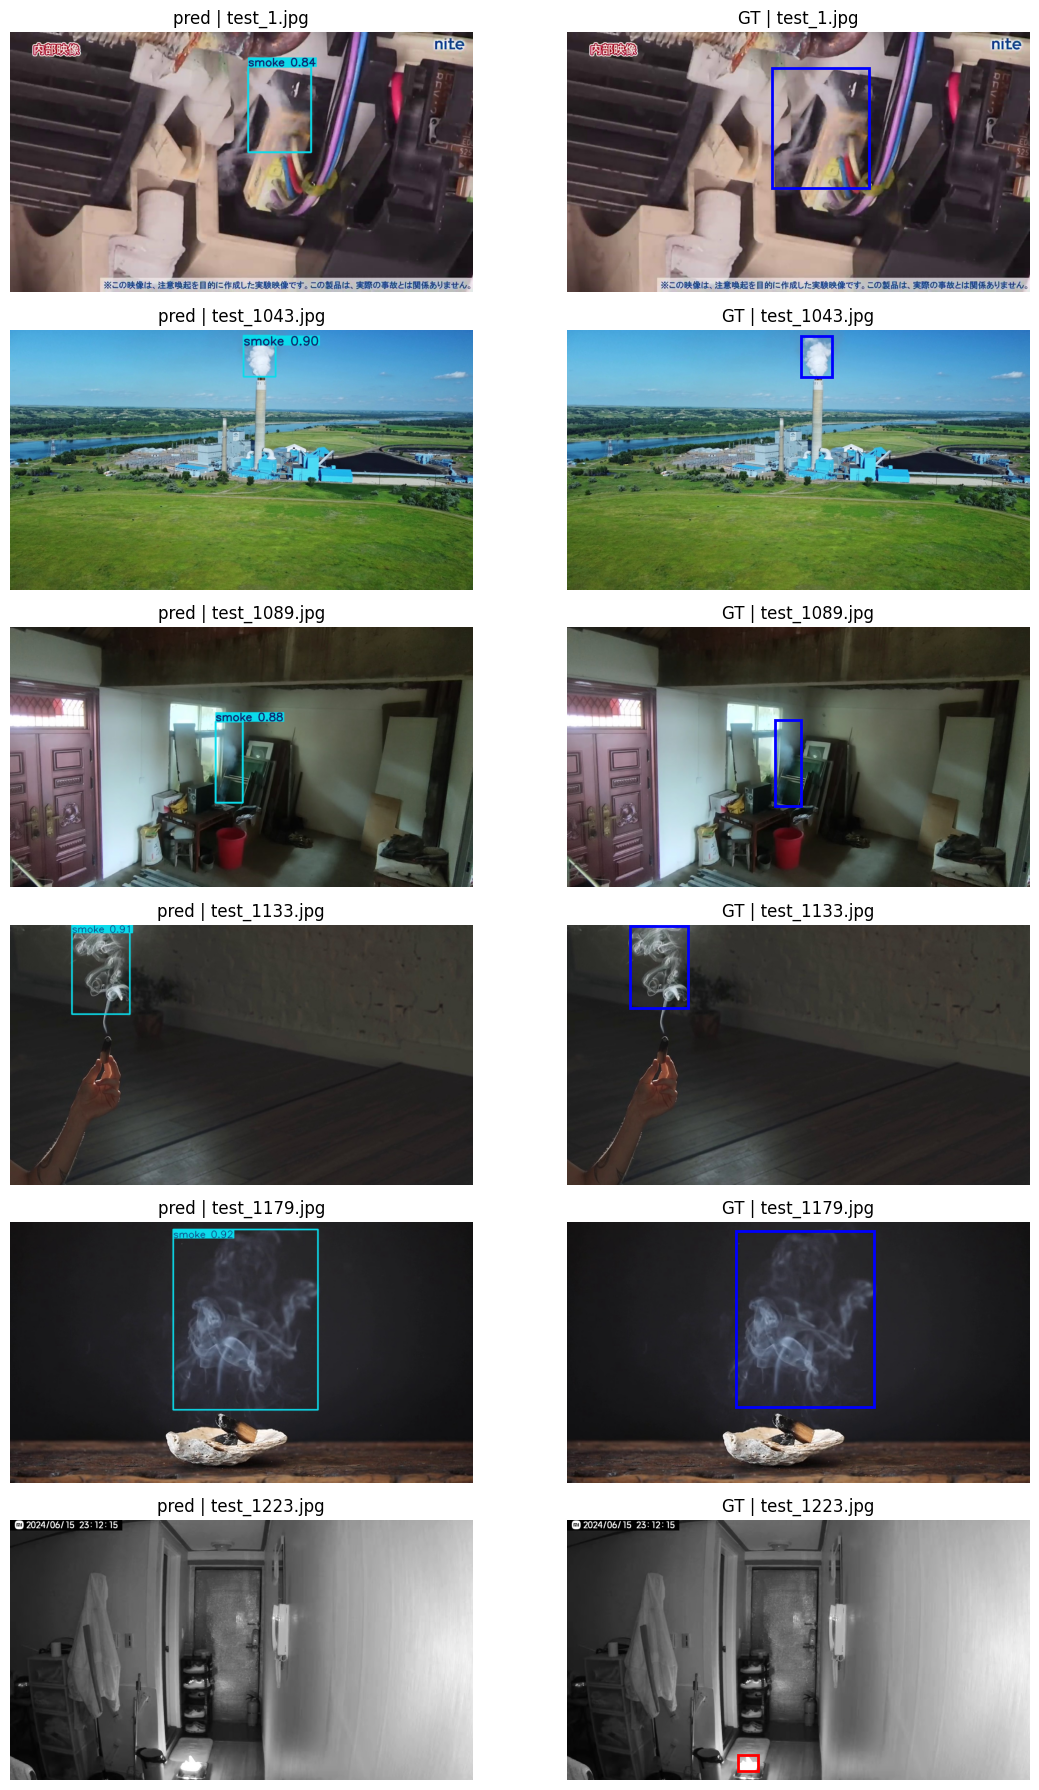

In [7]:
idxs = [0, 50, 100, 150, 200, 250]
fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 3 * len(idxs)))

for row, i in enumerate(idxs):
    img_path = test_images[i]
    label_path = DATA_DIR / "test" / "labels" / f"{img_path.stem}.txt"

    result = model.predict(source=str(img_path), verbose=False)[0]
    axes[row, 0].imshow(result.plot()[:, :, ::-1])
    axes[row, 0].set_title(f"pred | {img_path.name}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(Image.open(img_path))
    draw_bbox(axes[row, 1], label_path, img_path)
    axes[row, 1].set_title(f"GT | {img_path.name}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [10]:
test_metrics = model.val(data=str(DATA_YAML), split="test")
print_metrics("test (default conf)", test_metrics)

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 421.7161.1 MB/s, size: 236.0 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\labels... 1300 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300 954.4it/s 1.4s0.1s
val: New cache created: C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 13.2it/s 6.2s0.1s
                   all       1300       1586      0.899      0.825      0.897      0.568
                  fire        852        897      0.908      0.807      0.899      0.592
                 smoke        618        689      0.889      0.842      0.895      0.543
Speed: 0.6ms preprocess, 1.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\ea

Confidence done on the val split, not test, so we do not tune the threshold on the data we report final numbers on. We prioritize recall (F2) since missing a real fire/smoke is worse than a false alarm.

In [11]:
conf_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
sweep_rows = []

In [12]:
for conf in conf_values:
    m = model.val(data=str(DATA_YAML), split="val", conf=conf, verbose=False)
    p, r = float(m.box.mp), float(m.box.mr)
    sweep_rows.append((conf, p, r, f2_score(p, r)))
    print(f"conf={conf}  P={p}  R={r}  F2={f2_score(p, r)}")

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 2280.4472.2 MB/s, size: 251.7 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\val\labels.cache... 1300 images, 33 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 13.5it/s 6.1s0.1s
                   all       1300       1580      0.933      0.903      0.931      0.626
Speed: 0.6ms preprocess, 1.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\detect\val-4
conf=0.1  P=0.932786749822337  R=0.9029092061803505  F2=0.9087306092916386
Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 3264.1420.

In [13]:
best_conf = max(sweep_rows, key=lambda row: row[3])[0]
best_conf

0.4

In [ ]:
final_test_metrics = model.val(data=str(DATA_YAML), split="test", conf=best_conf)
print_metrics(f"test (conf=best{best_conf})", final_test_metrics)

Ultralytics 8.4.56  Python-3.11.15 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2299.1971.5 MB/s, size: 417.4 KB)
val: Scanning C:\Users\Arda\Desktop\Engineering\early-fire-detection\data\test\labels.cache... 1300 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1300/1300  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 82/82 12.7it/s 6.5s0.2s
                   all       1300       1586      0.911      0.813      0.804      0.519
                  fire        852        897       0.92      0.794      0.785      0.533
                 smoke        618        689      0.902      0.832      0.823      0.504
Speed: 0.6ms preprocess, 1.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\Arda\Desktop\Engineering\early-fire-detection\models\yolo26n\detect\val-11

=== test (conf=0.4) ===
P=0.9111294227756415  R=0.812698512

In [15]:
import numpy as np

speeds = []
for img_path in test_images[:50]:
    result = model.predict(source=str(img_path), verbose=False)[0]
    speeds.append(result.speed["inference"])

mean_ms = np.mean(speeds)
mean_ms

np.float64(15.263163999989047)